# Task 07 – Multi-feature Car Price Prediction with Visualizations
Date: 23-02-2026

---

## Problem Statement
1. Create a dataset of cars with multiple features:  
   - Numerical: `engine`, `mileage`, `age`, `doors`, `power`  
   - Categorical: `brand`, `fuel_type`  
   - Target: `price` (in INR)  
2. Train a **linear regression model** to predict car prices.  
3. Display **scatter plots** for numerical features vs price.  
4. Display **bar chart** for average price by brand.  
5. Show **correlation heatmap** for numeric features.  
6. Interpret insights from the plots and model.

---

## Code

Predicted Prices: [317321.19219935 360518.4044761  587537.01855113]
Actual Prices: [300000 400000 500000]
R² Score: 0.5239225149429447


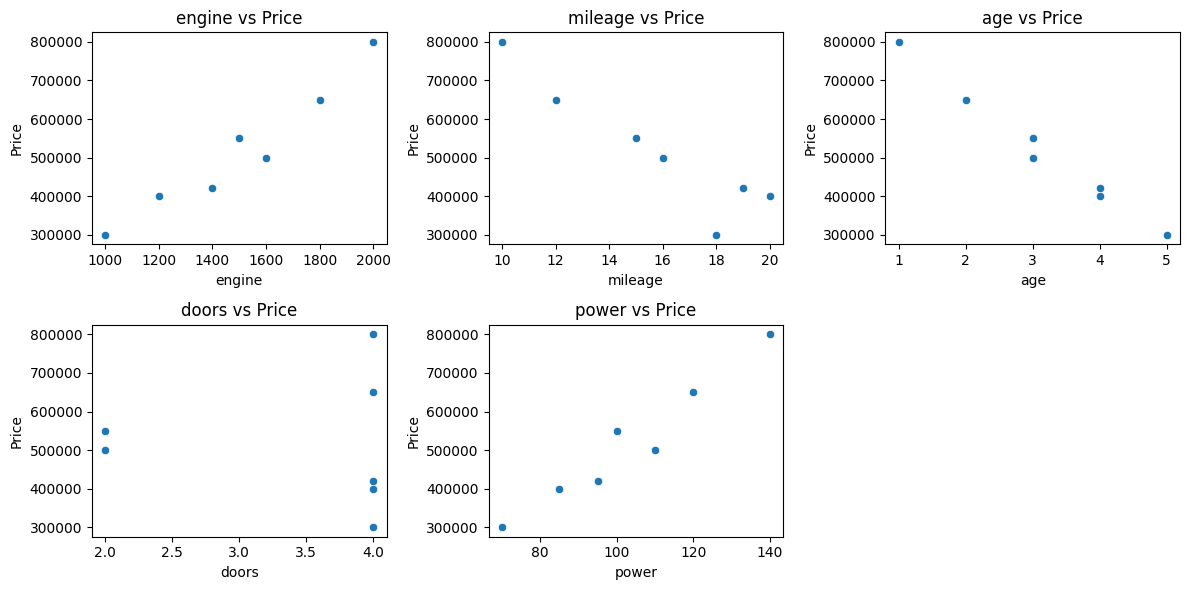

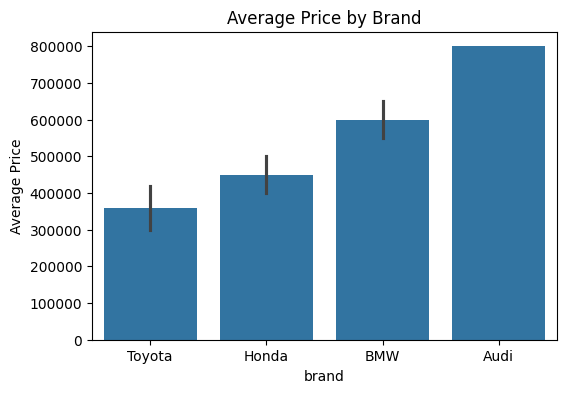

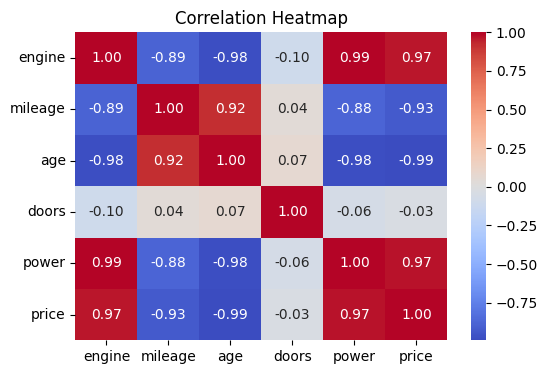


Feature Impact:
brand_Audi impact on price: 1847.6027582003449
brand_BMW impact on price: 2324.961029612868
brand_Toyota impact on price: -4172.563787813233
fuel_type_Diesel impact on price: -8642.797745898417
fuel_type_Petrol impact on price: 8642.797745898417
engine impact on price: -12.4295440502583
mileage impact on price: -12517.56706799919
age impact on price: -3397.535346128775
doors impact on price: -13590.389975396103
power impact on price: 5362.250105377017


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Dataset
data = {
    "engine": [1000, 1200, 1500, 1800, 2000, 1600, 1400],
    "mileage": [18, 20, 15, 12, 10, 16, 19],
    "age": [5, 4, 3, 2, 1, 3, 4],
    "doors": [4, 4, 2, 4, 4, 2, 4],
    "power": [70, 85, 100, 120, 140, 110, 95],
    "brand": ["Toyota", "Honda", "BMW", "BMW", "Audi", "Honda", "Toyota"],
    "fuel_type": ["Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Petrol", "Diesel"],
    "price": [300000, 400000, 550000, 650000, 800000, 500000, 420000]
}
df = pd.DataFrame(data)

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

categorical_features = ["brand", "fuel_type"]
numeric_features = ["engine", "mileage", "age", "doors", "power"]

# Preprocessing with handle_unknown='ignore'
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
], remainder="passthrough")

# Linear Regression pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Model performance
r2 = r2_score(y_test, y_pred)
print("Predicted Prices:", y_pred)
print("Actual Prices:", y_test.values)
print("R² Score:", r2)

# Scatter plots for numeric features vs price
plt.figure(figsize=(12,6))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(x=df[feature], y=df["price"])
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")
plt.tight_layout()
plt.show()

# Bar chart for average price by brand
plt.figure(figsize=(6,4))
sns.barplot(x="brand", y="price", data=df, estimator=np.mean)
plt.title("Average Price by Brand")
plt.ylabel("Average Price")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_features + ["price"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Feature impact
onehot_features = model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
all_features = list(onehot_features) + numeric_features
coefficients = model.named_steps['regressor'].coef_

print("\nFeature Impact:")
for f, c in zip(all_features, coefficients):
    print(f"{f} impact on price: {c}")

**Insights**
1. Scatter plots:
    - Price increases with engine size, power, and decreases with age.
    - Mileage negatively correlated with price (higher mileage cars tend to be cheaper).
2. Bar chart:
    - BMW and Audi cars have higher average prices compared to Toyota and Honda.
3. Correlation heatmap:
    - Engine, power, and age strongly correlate with price.
    - Mileage negatively correlates with price.
4. Model coefficients:
    - Brand (BMW, Audi) and fuel type (Diesel) positively impact price.
    - Engine and power positively influence price.
    - Age negatively impacts price.
5. R² Score: Indicates model fits small dataset well; on larger datasets, expect more realistic values.